In [8]:
import psycopg2
import datetime as dt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
db_params = {
    'host': '194.171.191.226',
    'port': '6379',
    'database': 'postgres',
    'user': 'group14',
    'password': 'blockd_2024group14_20'
}

In [3]:
conn = psycopg2.connect(**db_params)

In [4]:
cursor = conn.cursor()

# Additional Accidents data

In [6]:
get_data = '''SELECT * FROM data_lake.accident_data_17_23'''

cursor.execute(get_data)
df = pd.DataFrame(cursor.fetchall(), columns=['year', 'severity', 'municipality', 'town', 't1', 't2', 'area_type', 'light_condition', 'road_location', 'road_condition', 'road_surface', 'road_situation', 'speed_limit', 'street', 'weather', 'accidents'])

print(df.head())

   year severity municipality   town     t1          t2   area_type  \
0  2017    Fatal        Breda  BREDA    Car  Pedestrian  Urban area   
1  2017    Fatal        Breda  BREDA  Lorry       Other  Urban area   
2  2017    Fatal        Breda  BREDA  Lorry       Other  Urban area   
3  2017  Injured        Breda  BAVEL    Car       Lorry  Rural area   
4  2017  Injured        Breda  BAVEL    Car       Other  Rural area   

  light_condition road_location road_condition     road_surface  \
0        Darkness  Intersection       Wet/damp            Brick   
1        Daylight  Intersection       Wet/damp            Brick   
2        Daylight  Road section            Dry  Asphalt (other)   
3        Darkness  Road section       Wet/damp  Asphalt (other)   
4        Darkness  Road section       Wet/damp   Porous asphalt   

          road_situation speed_limit           street weather  accidents  
0                   Bend     30 km/h  Valkeniersplein    Rain          1  
1  Intersection - 4 

# Check Weather data

In [17]:
get_data = '''SELECT RI_PWS_10, RI_REGENM_10 FROM data_lake.precipitation'''

cursor.execute(get_data)
df = pd.DataFrame(cursor.fetchall(), columns=['normal', 'electric'])

print(df.head())

   normal  electric
0     0.0       0.0
1     0.0       0.0
2     0.0       0.0
3     0.0       0.0
4     0.0       0.0


In [23]:
same = df[df['normal'] - df['electric'] <= 10].count()
print(same)
print(df.count())

normal      1079643
electric    1079643
dtype: int64
normal      1079941
electric    1079850
dtype: int64


# Check AccidentsData

In [5]:
get_data = '''SELECT * FROM group14_warehouse.regression_data'''

cursor.execute(get_data)
df = pd.DataFrame(cursor.fetchall(), columns=['datetime_s', 'datetime_e', 'event_cat', 'event_sev', 'speed', 'end_speed',
                                                  'maxwaarde', 'streetname', 'rain_intensity', 'temperature', 'windspeed',
                                                  'speed_limit', 'light_condition', 'accident_sev', 'accident_prob'])

print(df.head())

               datetime_s              datetime_e        event_cat event_sev  \
0 2018-01-01 00:21:41.100 2018-01-01 00:21:43.500  HARSH CORNERING       HC1   
1 2018-01-01 00:18:20.500 2018-01-01 00:18:28.500            SPEED       SP1   
2 2018-01-01 00:18:20.500 2018-01-01 00:18:28.500            SPEED       SP1   
3 2018-01-01 00:18:20.500 2018-01-01 00:18:28.500            SPEED       SP1   
4 2018-01-01 00:18:20.500 2018-01-01 00:18:28.500            SPEED       SP1   

       speed  end_speed  maxwaarde         streetname  rain_intensity  \
0  30.577536  37.014910   0.854562       Doornboslaan             0.0   
1  82.076546  82.076546  86.904580  Backer en Ruebweg             0.0   
2  82.076546  82.076546  86.904580  Backer en Ruebweg             0.0   
3  82.076546  82.076546  86.904580  Backer en Ruebweg             0.0   
4  82.076546  82.076546  86.904580  Backer en Ruebweg             0.0   

   temperature  windspeed speed_limit light_condition          accident_sev  \
0

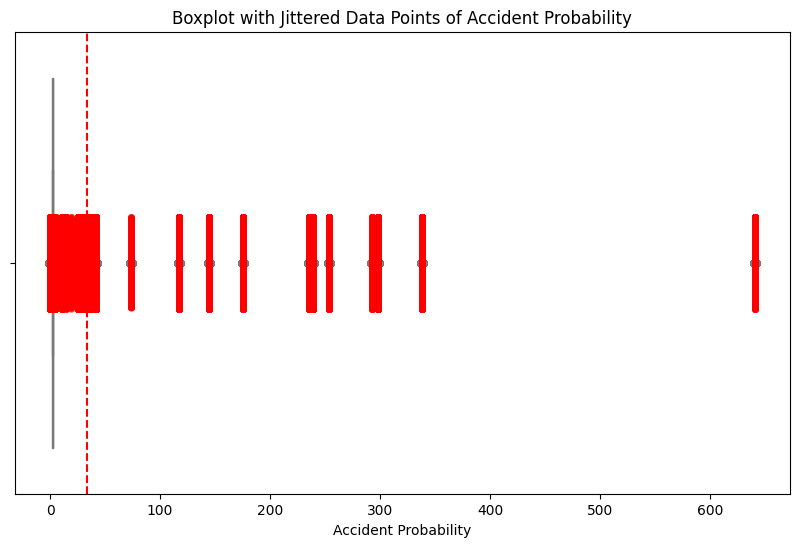

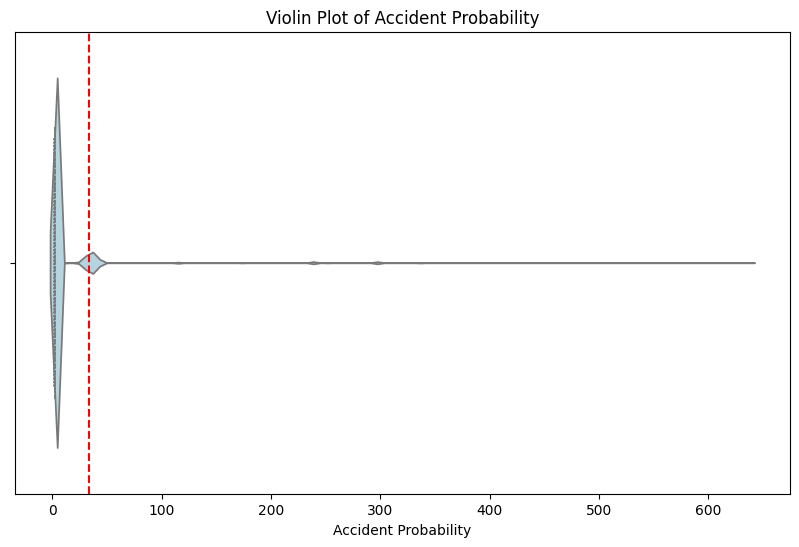

In [13]:
# Calculate the 95th percentile
percentile_95 = df['accident_prob'].quantile(0.97)

# Plot the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='accident_prob', data=df, color='lightblue')
sns.stripplot(x='accident_prob', data=df, color='red', alpha=0.5, jitter=True)
plt.axvline(percentile_95, color='red', linestyle='--', label='95th Percentile')
plt.title('Boxplot with Jittered Data Points of Accident Probability')
plt.xlabel('Accident Probability')
plt.show()

# Using a violin plot for more detail
plt.figure(figsize=(10, 6))
sns.violinplot(x='accident_prob', data=df, inner='quartile', color='lightblue')
plt.axvline(percentile_95, color='red', linestyle='--', label='95th Percentile')
plt.title('Violin Plot of Accident Probability')
plt.xlabel('Accident Probability')
plt.show()

In [14]:
print(percentile_95)

33.17602642756017
